# Griffiths Ch. 4 — Electric Fields in Matter

What changes when the field is inside *stuff*. Matter polarizes: each atom becomes a tiny dipole,
the dipoles sum to a polarization field $\mathbf P$, and $\mathbf P$ produces **bound charge**
($\sigma_b=\mathbf P\cdot\hat n$, $\rho_b=-\nabla\cdot\mathbf P$). Bookkeeping the free charge
separately gives the displacement $\mathbf D=\epsilon_0\mathbf E+\mathbf P$, and for linear
dielectrics everything collapses to one constant, $\epsilon_r=1+\chi_e$.

The capstone reuses Ch. 3 directly: a **dielectric sphere in a uniform field** is the same Legendre
separation of variables, now with dielectric boundary conditions — and the answer,
$\mathbf E_{\rm in}=\frac{3}{\epsilon_r+2}\mathbf E_0$, interpolates between vacuum and a conductor.
Engine: `griffiths.dielectrics`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import dielectrics as di
from griffiths import electrostatics as es

sp.init_printing(use_latex="mathjax")
P, a, E0, chi, R = sp.symbols("P a E_0 chi_e R", positive=True)
eps_r = sp.Symbol("epsilon_r", positive=True)
theta = sp.Symbol("theta")
print("griffiths.dielectrics loaded")

griffiths.dielectrics loaded


## §1 Polarization and bound charge

A polarized medium hides charge at its surfaces and (if $\mathbf P$ varies) in its volume:

$$\sigma_b=\mathbf P\cdot\hat n,\qquad \rho_b=-\nabla\cdot\mathbf P.$$

For a uniformly polarized object $\rho_b=0$ — all the bound charge sits on the surface.

In [2]:
# uniform P along z on a sphere: outward normal . z-hat = cos(theta)
display(Math(r"\sigma_b = \mathbf P\cdot\hat n = " + sp.latex(di.bound_surface_charge(P, theta))
             + r"\quad(\text{a pure } P_1(\cos\theta)\text{ distribution})"))
x, y, z = gr.x, gr.y, gr.z
P_uniform = sp.Matrix([0, 0, P])
display(Math(r"\rho_b = -\nabla\cdot\mathbf P = " + sp.latex(di.bound_volume_charge(P_uniform))
             + r"\quad(\text{uniform }\mathbf P)"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §2 Atomic polarizability (Griffiths 4.1)

Put an atom in a field and its electron cloud shifts until the restoring pull balances the field; the
induced dipole is $\mathbf p=\alpha\mathbf E$. For a sphere of radius $a$ the model gives
$\alpha=4\pi\epsilon_0 a^3$ — polarizability scales as *volume*.

In [3]:
alpha = di.polarizability_sphere(a)
display(Math(r"\alpha = " + sp.latex(alpha) + r" = 4\pi\epsilon_0 a^3"))
display(Math(r"\mathbf p = \alpha\mathbf E = " + sp.latex(di.induced_dipole(alpha, E0)) + r"\,\hat z"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 The uniformly polarized sphere

The surface charge $\sigma_b=P\cos\theta$ is exactly a Legendre $l=1$ term — so the Ch. 3 machinery
applies and the interior field is **uniform**, the exterior a **pure dipole**:

$$\mathbf E_{\rm in}=-\frac{\mathbf P}{3\epsilon_0},\qquad
\mathbf p=\tfrac43\pi R^3\,\mathbf P\ (\text{exterior dipole}).$$

<IPython.core.display.Math object>

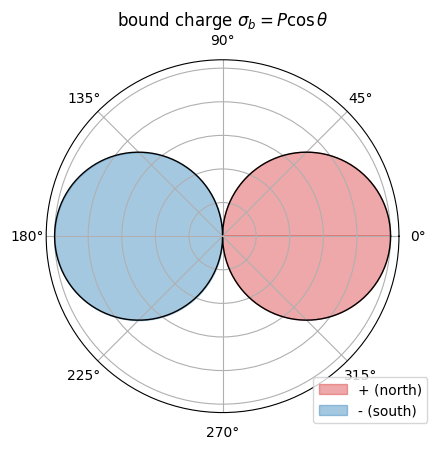

In [4]:
E_in = di.uniformly_polarized_sphere(P)
display(Math(r"\mathbf E_{\rm in} = " + sp.latex(E_in) + r"\,\hat z = -\frac{\mathbf P}{3\epsilon_0}"))

# the bound surface charge sigma_b = P cos(theta), drawn around the sphere
th = np.linspace(0, 2*np.pi, 200)
sigma = np.cos(th)
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4.6, 4.6))
ax.plot(th, np.abs(sigma), color="k", lw=1)
ax.fill_between(th, 0, np.abs(sigma), where=(sigma > 0), color="C3", alpha=0.4, label="+ (north)")
ax.fill_between(th, 0, np.abs(sigma), where=(sigma < 0), color="C0", alpha=0.4, label="- (south)")
ax.set_title(r"bound charge $\sigma_b = P\cos\theta$"); ax.set_yticklabels([])
ax.legend(loc="lower right", bbox_to_anchor=(1.1, -0.05)); plt.tight_layout(); plt.show()

## §4 Linear dielectrics and the displacement field

Define $\mathbf D=\epsilon_0\mathbf E+\mathbf P$ so that $\nabla\cdot\mathbf D=\rho_{\rm free}$ —
the free charge alone sources $\mathbf D$. In a linear medium $\mathbf P=\epsilon_0\chi_e\mathbf E$,
hence $\mathbf D=\epsilon\mathbf E$ with $\epsilon=\epsilon_0\epsilon_r$ and

$$\boxed{\ \epsilon_r=1+\chi_e\ }.$$

In [5]:
Evec = sp.Matrix([0, 0, E0]); Pvec = sp.Matrix([0, 0, es.eps0*chi*E0])
display(Math(r"\mathbf D = \epsilon_0\mathbf E + \mathbf P = " + sp.latex(di.displacement_field(Evec, Pvec).T)
             + r" = \epsilon_0(1+\chi_e)\mathbf E"))
display(Math(r"\epsilon_r = " + sp.latex(di.dielectric_constant(chi))))
C0 = sp.Symbol("C_0", positive=True)
display(Math(r"\text{capacitor with dielectric: } C = " + sp.latex(di.capacitor_with_dielectric(eps_r, C0))
             + r" = \epsilon_r C_0"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §5 The capstone: a dielectric sphere in a uniform field

Same Legendre BVP as Ch. 3, now with the dielectric conditions ($V$ continuous, $D_\perp$ continuous
since there is no free surface charge). The interior field is uniform and **screened**:

$$\mathbf E_{\rm in}=\frac{3}{\epsilon_r+2}\,\mathbf E_0.$$

It smoothly interpolates: $\epsilon_r\to1$ gives $\mathbf E_{\rm in}=\mathbf E_0$ (vacuum, no
screening); $\epsilon_r\to\infty$ gives $\mathbf E_{\rm in}\to0$ (a conductor expels the field).

In [6]:
res = di.dielectric_sphere_in_field(eps_r, E0, R)
display(Math(r"V_{\rm in} = A\,r\cos\theta,\quad A = " + sp.latex(res["A"])))
display(Math(r"V_{\rm out} = (-E_0 r + B/r^2)\cos\theta,\quad B = " + sp.latex(res["B"])))
display(Math(r"\mathbf E_{\rm in} = " + sp.latex(res["E_in"]) + r"\,\hat z,\qquad "
             r"\frac{E_{\rm in}}{E_0} = " + sp.latex(res["E_in_over_E0"])))
print("limits:  eps_r->1 (vacuum):", sp.limit(res["E_in_over_E0"], eps_r, 1),
      "   eps_r->oo (conductor):", sp.limit(res["E_in_over_E0"], eps_r, sp.oo))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

limits:  eps_r->1 (vacuum): 1    eps_r->oo (conductor): 0


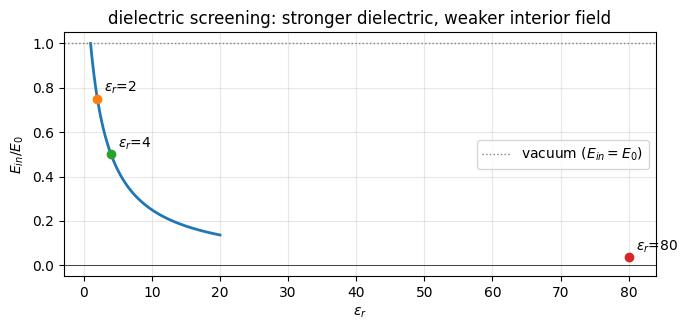

In [7]:
# screening factor vs eps_r
ers = np.linspace(1, 20, 200)
plt.figure(figsize=(7, 3.4))
plt.plot(ers, 3/(ers+2), lw=2)
plt.axhline(1, color="gray", ls=":", lw=1, label="vacuum ($E_{in}=E_0$)")
plt.axhline(0, color="k", lw=0.5)
for er in (2, 4, 80):
    plt.plot(er, 3/(er+2), "o"); plt.annotate(f"$\\epsilon_r$={er}", (er, 3/(er+2)),
                                               textcoords="offset points", xytext=(5, 5))
plt.xlabel(r"$\epsilon_r$"); plt.ylabel(r"$E_{in}/E_0$")
plt.title("dielectric screening: stronger dielectric, weaker interior field")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

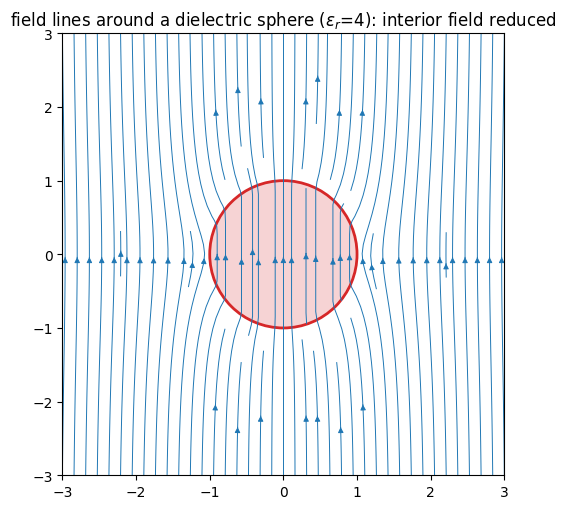

In [8]:
# field lines: uniform E0 distorted by a dielectric sphere (eps_r = 4)
er = 4.0; E0n = 1.0; Rn = 1.0
A = -3*E0n/(er+2); B = E0n*Rn**3*(er-1)/(er+2)
gx = np.linspace(-3, 3, 240); gy = np.linspace(-3, 3, 240)
X, Y = np.meshgrid(gx, gy)
r = np.sqrt(X**2 + Y**2) + 1e-9
# potential V(x,z): inside V=A*z, outside V=-E0 z + B z/r^3  (z<->Y here)
V = np.where(r < Rn, A*Y, -E0n*Y + B*Y/r**3)
Ey, Ex = np.gradient(-V, gy, gx)
plt.figure(figsize=(5.6, 5.2))
plt.streamplot(X, Y, Ex, Ey, density=1.3, color="C0", linewidth=0.7, arrowsize=0.8)
circ = plt.Circle((0, 0), Rn, color="C3", alpha=0.2)
plt.gca().add_patch(circ)
plt.gca().add_patch(plt.Circle((0, 0), Rn, fill=False, color="C3", lw=2))
plt.gca().set_aspect("equal"); plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.title(f"field lines around a dielectric sphere ($\\epsilon_r$={er:.0f}): interior field reduced")
plt.tight_layout(); plt.show()

## §6 Clausius-Mossotti, and where this lands

The **Clausius-Mossotti** relation bridges the microscopic polarizability $\alpha$ and the
macroscopic constant: $\dfrac{\epsilon_r-1}{\epsilon_r+2}=\dfrac{N\alpha}{3\epsilon_0}$. That same
$\epsilon_r+2$ from the sphere problem reappears — the local-field correction is the dielectric
sphere seen from the inside.

In [9]:
N = sp.Symbol("N", positive=True)
er_cm = di.clausius_mossotti(N, di.polarizability_sphere(a))
display(Math(r"\frac{\epsilon_r-1}{\epsilon_r+2} = \frac{N\alpha}{3\epsilon_0}"
             r"\;\Rightarrow\; \epsilon_r = " + sp.latex(sp.simplify(er_cm))))

<IPython.core.display.Math object>

**Through-line to the repo.**

- **Dielectric = optical index.** $\epsilon_r=n^2$: the core/cladding index contrast that guides the
  fibre LP modes (the Bessel notebook) *is* a dielectric boundary-value problem — §5 is the
  electrostatic cousin of mode confinement.
- **Polarizability → dispersion.** Frequency-dependent $\alpha(\omega)$ gives $\epsilon(\omega)$ and
  hence the group-velocity dispersion the TD-GS pipeline lives on; the static $\alpha=4\pi\epsilon_0a^3$
  here is the $\omega\to0$ end of that curve.
- **Same Legendre, new boundary condition.** §5 reuses Ch. 3's separation of variables verbatim —
  the method is the constant, the physics swaps in at the boundary.

Engine added this session: `griffiths/dielectrics.py` (bound charge, polarizability, displacement
field, linear-dielectric relations, the dielectric-sphere BVP, Clausius-Mossotti), benchmarked in
`scripts/smoke_dielectrics.py`. The `griffiths` package now spans Griffiths Ch. 1-4.